In [2]:
import os
try:
    import docx
except ImportError:
    !pip install python-docx
    import docx

doc_path = '/content/STUDENT PROCEDURAL MANUAL - Lab 5.docx'
if os.path.exists(doc_path):
    doc = docx.Document(doc_path)
    print(f"Document Loaded Successfully! Total Paragraphs: {len(doc.paragraphs)}")

    print("\n--- Complete Document Text ---")
    for i, paragraph in enumerate(doc.paragraphs):
        if paragraph.text.strip():
            print(f"[{i}]: {paragraph.text}")
else:
    print(f"File not found at: {doc_path}")

Document Loaded Successfully! Total Paragraphs: 145

--- Complete Document Text ---
[4]: College of Computer Science and Information Technology
[5]: تامولعملا ةينقتو بساحلا مولع ةيلك
[33]: DEPARTMENT OF COMPUTER ENGINEERING
[52]: ARTI 406 – Image Processing
[55]: STUDENT PROCEDURAL MANUAL Lab 5
[59]: 2025 - 2026
[63]: Practical Session Plan
[68]: 1- Session Outcomes
[70]: Outcome#2: Write a program that implements fundamental image processing algorithms.
[72]: 2- Tool(s)/Software	.
[73]: •	Python 3
[74]: •	Anaconda
[75]: •	IDE for Python: Jupyter, Spyder.
[76]: •	Libraries: OpenCV, NumPy, Pillow, Skimage, Matplotlib.
[80]: 3- Procedural steps (Tasks)
[83]: Task#1: Unsharp Masking
[84]: # Read the image
[85]: image = cv2.imread('images/Parrot.png')
[86]: image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert from BGR to RGB
[88]: # Gaussian sigma
[89]: sigma=2
[91]: #parameter
[92]: amount=1.5
[94]: # Convert image to float32 for processing
[95]: image_float = image.astype(np.float32

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Create a high-quality sample image of choice (a synthetic colorful geometric pattern with textures)
# This ensures the code runs immediately and displays distinct features for filtering/sharpening
width, height = 512, 512
img = np.zeros((height, width, 3), dtype=np.uint8)

# Draw some shapes
cv2.circle(img, (256, 256), 120, (100, 240, 120), -1) # Green circle
cv2.rectangle(img, (100, 100), (412, 412), (220, 100, 50), 8) # Blue rectangle outline
cv2.putText(img, 'LAB 5', (180, 270), cv2.FONT_HERSHEY_SIMPLEX, 2, (255, 255, 255), 5) # White text

# Save as local image of choice
cv2.imwrite('sample_image.png', img)
print("Sample image 'sample_image.png' created successfully for the tasks!")

Sample image 'sample_image.png' created successfully for the tasks!


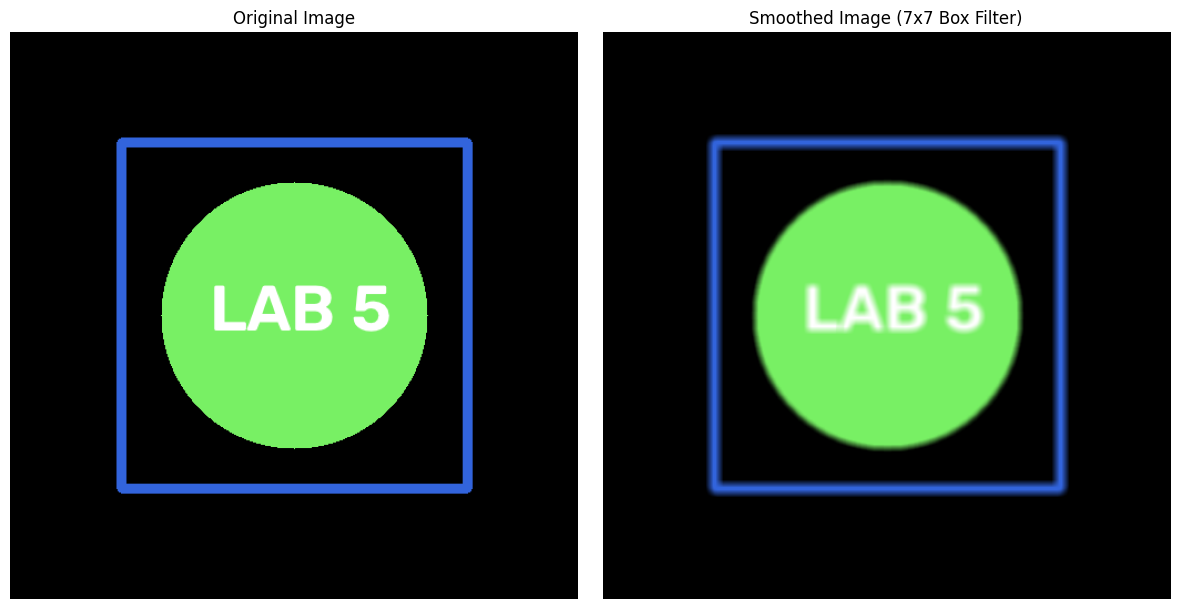

In [4]:
# Task 1: Convolve an image with a 7x7 box filter, and output the original and smoothed image side by side
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read the image and convert to RGB
img = cv2.imread('sample_image.png')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Apply 7x7 box filter (average blur)
smoothed_img = cv2.blur(img_rgb, (7, 7))

# Plot original and smoothed image side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(img_rgb)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(smoothed_img)
axes[1].set_title("Smoothed Image (7x7 Box Filter)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

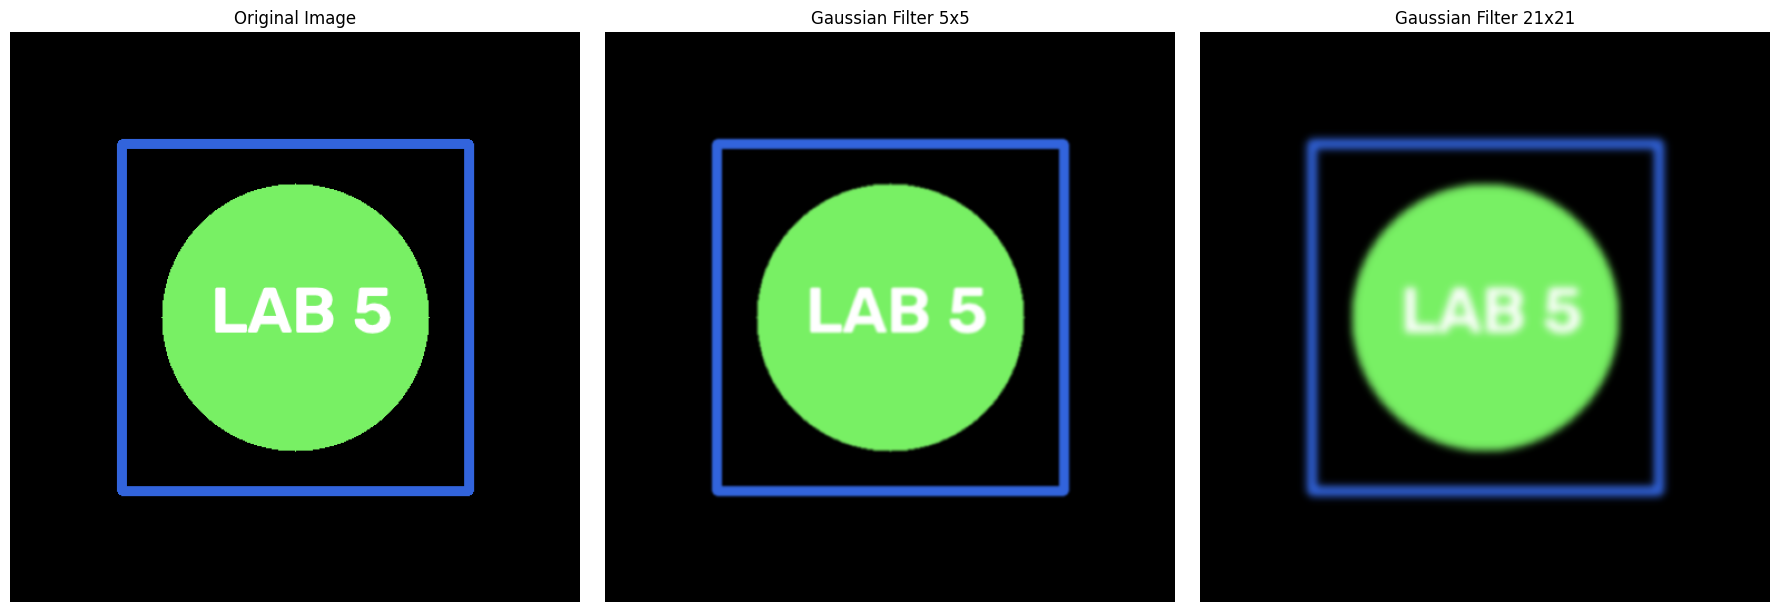

In [5]:
# Task 2: Using an image of your choice, apply a 5x5 Gaussian filter to the image,
# then a 21x21 Gaussian filter, and show the three images side by side.

# Apply 5x5 Gaussian filter
gaussian_5x5 = cv2.GaussianBlur(img_rgb, (5, 5), 0)

# Apply 21x21 Gaussian filter
gaussian_21x21 = cv2.GaussianBlur(img_rgb, (21, 21), 0)

# Plot original, 5x5 Gaussian, and 21x21 Gaussian side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img_rgb)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(gaussian_5x5)
axes[1].set_title("Gaussian Filter 5x5")
axes[1].axis("off")

axes[2].imshow(gaussian_21x21)
axes[2].set_title("Gaussian Filter 21x21")
axes[2].axis("off")

plt.tight_layout()
plt.show()

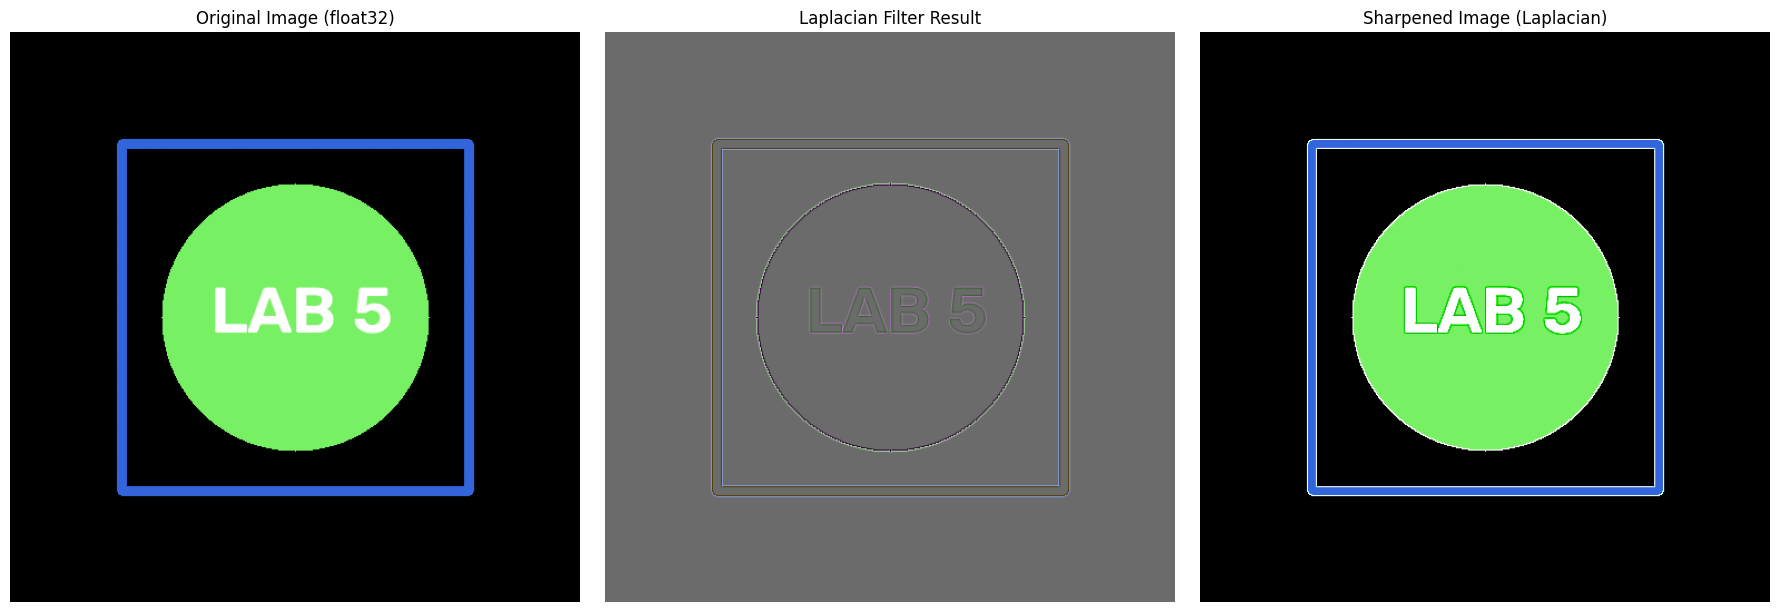

In [6]:
# Task 3: Using an image of your choice, apply a 3x3 Laplacian filter to sharpen the image.
# Step 1: Read the image
image = cv2.imread('sample_image.png')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Step 2: Convert image to float32
image_float = image.astype(np.float32) / 255.0

# Step 3: Use the cv2.Laplacian() function (with 3x3 aperture size ksize=3)
laplacian = cv2.Laplacian(image_float, cv2.CV_32F, ksize=3)

# Step 4: Sharpen the image using the formula from manual
sharpened = np.clip(image_float - laplacian, 0, 1)

# Step 5: Plot original, laplacian, and sharpened images
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(image_float)
axes[0].set_title("Original Image (float32)")
axes[0].axis("off")

# Normalize laplacian visualization to [0, 1] for displaying correctly in matplotlib
laplacian_vis = np.clip((laplacian - laplacian.min()) / (laplacian.max() - laplacian.min() + 1e-5), 0, 1)
axes[1].imshow(laplacian_vis)
axes[1].set_title("Laplacian Filter Result")
axes[1].axis("off")

axes[2].imshow(sharpened)
axes[2].set_title("Sharpened Image (Laplacian)")
axes[2].axis("off")

plt.tight_layout()
plt.show()